### libraries

In [1]:
pip install tensorflow keras nltk scikit-learn matplotlib pandas

,Requirement already satisfied: keras in /usr/local/lib/python3.12/dist-packages (3.13.2)
,Requirement already satisfied: nltk in /usr/local/lib/python3.12/dist-packages (3.9.1)
,Requirement already satisfied: scikit-learn in /usr/local/lib/python3.12/dist-packages (1.6.1)
,Requirement already satisfied: matplotlib in /usr/local/lib/python3.12/dist-packages (3.10.0)
,Requirement already satisfied: pandas in /usr/local/lib/python3.12/dist-packages (2.2.2)
,Requirement already satisfied: absl-py>=1.0.0 in /usr/local/lib/python3.12/dist-packages (from tensorflow) (1.4.0)
,Requirement already satisfied: astunparse>=1.6.0 in /usr/local/lib/python3.12/dist-packages (from tensorflow) (1.6.3)
,Requirement already satisfied: flatbuffers>=24.3.25 in /usr/local/lib/python3.12/dist-packages (from tensorflow) (25.12.19)
,Requirement already satisfied: gast!=0.5.0,!=0.5.1,!=0.5.2,>=0.2.1 in /usr/local/lib/python3.12/dist-packages (from tensorflow) (0.7.0)
,Requirement already satisfied: google_pasta

###import lib

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


### load dataset

In [4]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


,17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
,Training samples: 25000
,Testing samples: 25000


### sentence length distribution

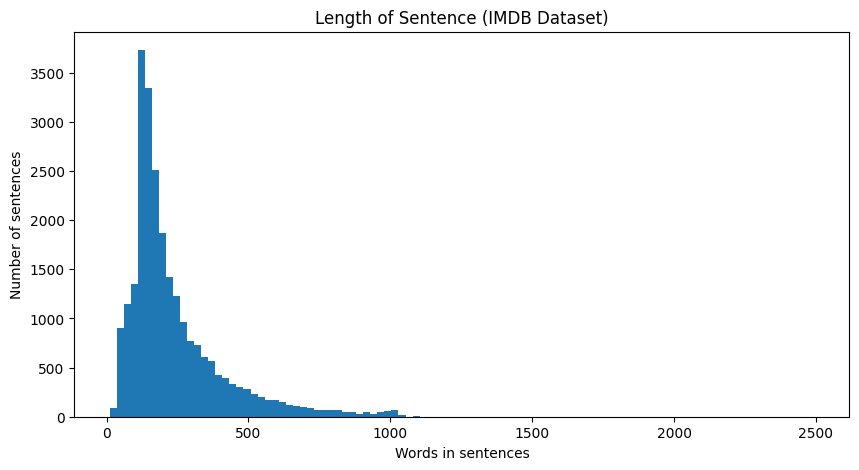

In [5]:

review_lengths = [len(review) for review in X_train]

plt.figure(figsize=(10,5))

plt.hist(review_lengths, bins=100)

plt.title("Length of Sentence (IMDB Dataset)")
plt.xlabel("Words in sentences")
plt.ylabel("Number of sentences")

plt.show()


### padding sequences

In [6]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (25000, 200)
,Shape of X_test: (25000, 200)


### LSTM

In [11]:
from tensorflow.keras.layers import Input

model = Sequential()

model.add(Input(shape=(max_len,)))

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    )
)

model.add(
    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    )
)

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

### Compile model

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,559,681 (5.95 MB)

 Trainable params: 1,559,681 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

### early stopping

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### train model

In [20]:

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
,313/313 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - accuracy: 0.9319 - loss: 0.1823 - val_accuracy: 0.8466 - val_loss: 0.3992
,Epoch 2/5
,313/313 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - accuracy: 0.9539 - loss: 0.1288 - val_accuracy: 0.8466 - val_loss: 0.5083
,Epoch 3/5
,313/313 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.9630 - loss: 0.1058 - val_accuracy: 0.8162 - val_loss: 0.6076
,Epoch 4/5
,313/313 ━━━━━━━━━━━━━━━━━━━━ 440s 1s/step - accuracy: 0.9723 - loss: 0.0804 - val_accuracy: 0.8426 - val_loss: 0.5870
,Epoch 5/5
,313/313 ━━━━━━━━━━━━━━━━━━━━ 442s 1s/step - accuracy: 0.9814 - loss: 0.0551 - val_accuracy: 0.8378 - val_loss: 0.7036


### evaluate model

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 123s 157ms/step - accuracy: 0.8453 - loss: 0.3999
,
,Test Loss: 0.3999057710170746
,Test Accuracy: 0.8452799916267395


### predictions

In [22]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype("int32")

782/782 ━━━━━━━━━━━━━━━━━━━━ 125s 159ms/step


### classification report

In [23]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


,Classification Report:
,
,              precision    recall  f1-score   support
,
,           0       0.84      0.86      0.85     12500
,           1       0.85      0.84      0.84     12500
,
,    accuracy                           0.85     25000
,   macro avg       0.85      0.85      0.85     25000
,weighted avg       0.85      0.85      0.85     25000
,


### confusion matrix

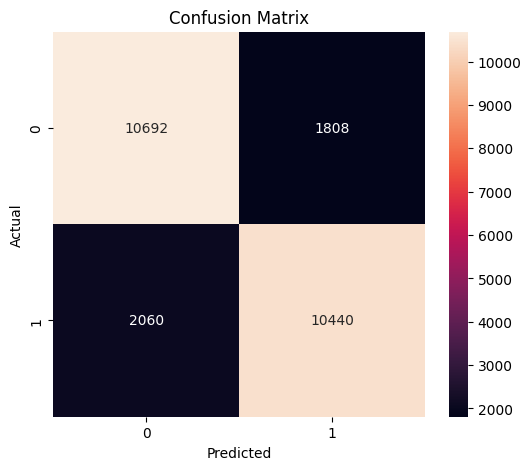

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### accuracy graph

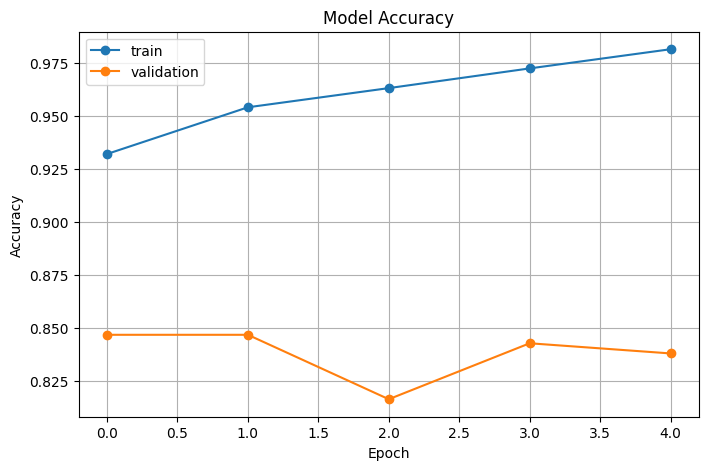

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    marker='o',
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    marker='o',
    label='validation'
)

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.grid(True)

plt.legend()

plt.show()

### loss graph

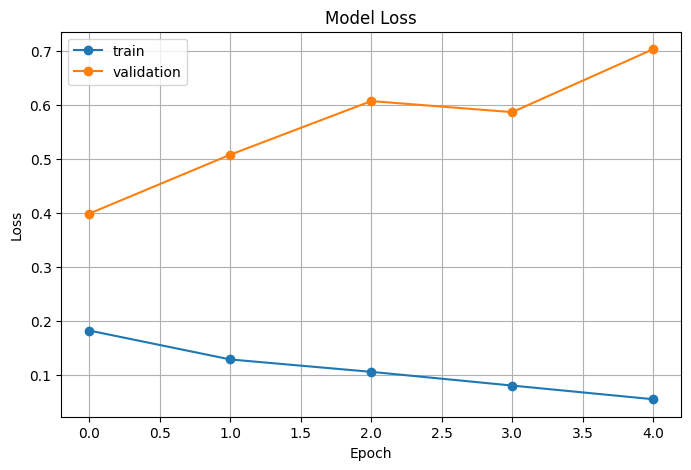

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    marker='o',
    label='train'
)

plt.plot(
    history.history['val_loss'],
    marker='o',
    label='validation'
)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.grid(True)

plt.legend()

plt.show()

### save model

In [27]:
model.save("imdb_lstm_model.h5")

print("\nModel saved successfully!")


,Model saved successfully!
